# Spatial grid binning and differential expression

Cell-type-based differential expression (notebooks 1 and 2) requires accurate cell segmentation and annotation. As a complementary, annotation-free approach, this notebook aggregates raw transcript data into **spatial grid bins** and performs differential expression at the bin level.

Each bin represents a 30 µm × 30 µm square of tissue. Transcripts within a bin are summed to produce a pseudo-bulk count matrix that preserves spatial structure without relying on single-cell segmentation. This allows detection of spatially coherent gene expression differences between conditions — for example, gradients or focal regions of immune activation — that might be missed or diluted in a per-cell analysis.

The same pairwise comparisons used in the cell-level analysis are applied here, enabling a cross-validation of key findings across both levels of resolution.

In [107]:
import os
import os
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse

def grid_adata_from_transcripts(
    transcripts_df: pd.DataFrame,
    grid_size: int = 30,
    x_col: str = "x_location",
    y_col: str = "y_location",
    gene_col: str = "feature_name",
    center_bins: bool = False,
):
    """
    Convert a transcripts table to a grid-binned AnnData (sparse).
    Required columns: x_col, y_col, gene_col
    """
    df = transcripts_df[[x_col, y_col, gene_col]].copy()

    # integer bins
    x_bin = (df[x_col] // grid_size).astype(np.int64)
    y_bin = (df[y_col] // grid_size).astype(np.int64)

    # build categorical ids for bins and genes
    # bin_id as "xbin_ybin" keeps things human-readable
    bin_id = x_bin.astype(str) + "_" + y_bin.astype(str)
    bin_codes, bin_cats = pd.factorize(bin_id, sort=True)
    gene_codes, gene_cats = pd.factorize(df[gene_col], sort=True)

    # sparse counts (one transcript per row)
    data = np.ones(len(df), dtype=np.int32)
    X = sparse.csr_matrix(
        (data, (bin_codes, gene_codes)),
        shape=(len(bin_cats), len(gene_cats))
    )

    # coordinates per bin
    # take the unique (x_bin, y_bin) for each bin_id
    # since we encoded bin_id from those, we can recover by splitting
    xb = pd.Series(bin_cats).str.split("_", expand=True).astype(np.int64)
    xb.columns = ["x_bin", "y_bin"]

    # spatial coordinates at corner (like your original) or bin center
    spatial = xb.values * grid_size
    if center_bins:
        spatial = spatial + grid_size / 2.0

    # build AnnData
    ad = sc.AnnData(X=X)
    ad.obs_names = bin_cats.astype(str)
    ad.var_names = gene_cats.astype(str)
    ad.obs[["x_bin", "y_bin"]] = xb.values
    ad.obsm["spatial"] = spatial

    # store grid size for reference
    ad.uns["grid_size_um"] = grid_size
    ad.uns["bin_centered"] = bool(center_bins)
    ad.obs["n_counts"] = np.asarray(X.sum(axis=1)).ravel()
    ad.var["n_counts"] = np.asarray(X.sum(axis=0)).ravel()

    return ad


def load_parquet_fast(path: str, columns=("x_location", "y_location", "feature_name")) -> pd.DataFrame:
    # only read needed columns for speed/memory
    return pd.read_parquet(path, columns=list(columns))


def build_grid_for_samples(
    base_dir: str,
    sample_ids: list,
    grid_size: int = 30,
    transcripts_relpath: str = "transcripts.parquet",
    center_bins: bool = False,
    save_dir: str | None = None,
    verbose: bool = True,
):
    """
    Iterate samples, build grid-binned AnnData per sample.
    Returns dict: {sample_id: AnnData}
    Optionally saves each to save_dir as <sample_id>.h5ad
    """
    os.makedirs(save_dir, exist_ok=True) if save_dir else None
    out = {}
    for sid in sample_ids:
        if sid == ".DS_Store":
            continue
        fpath = os.path.join(base_dir, sid, transcripts_relpath)
        if not os.path.exists(fpath):
            if verbose:
                print(f"[skip] not found: {fpath}")
            continue

        if verbose:
            print(f"[read] {sid}")

        try:
            tx = load_parquet_fast(fpath)
            ad = grid_adata_from_transcripts(
                tx, grid_size=grid_size, center_bins=center_bins
            )
            # keep provenance
            ad.uns["sample_id"] = sid
            ad.uns["transcripts_path"] = fpath

            if save_dir:
                out_path = os.path.join(save_dir, f"{sid}.h5ad")
                ad.write(out_path)
                if verbose:
                    print(f"[saved] {out_path}")

            out[sid] = ad

        except Exception as e:
            print(f"[error] {sid}: {e}")

    return out
    
import scanpy as sc
import re

def merge_grid_adatas(adatas_dict):
    """
    Merge multiple grid-binned AnnData objects into one unified object.
    Adds:
      - 'sample_id': the full sample folder name
      - 'condition': parsed from the substring like '__wt_72h__' → 'wt_72h'
    """
    merged_list = []

    for sid, ad in adatas_dict.items():
        # extract pattern like '__wt_72h__' or '__cre_24h__'
        m = re.search(r"__([^_]+_[^_]+)__", sid)
        condition = m.group(1) if m else "unknown"

        ad = ad.copy()
        ad.obs["sample_id"] = sid
        ad.obs["condition"] = condition  # clean version without __
        merged_list.append(ad)

    # concatenate (union of genes, fill missing with 0)
    ad_merged = sc.concat(
        merged_list,
        join="outer",
        label="sample_id",
        keys=[a.obs["sample_id"].unique()[0] for a in merged_list],
        fill_value=0,
    )

    return ad_merged

In [108]:
# given dictionary and list
comparisons = {
    "cre_24h_vs_litt_24h": {
        "case": ["output-XETG00045__0059976__cre_24h__20250725__091031"],
        "control": ["output-XETG00045__0059976__litt_24h__20250725__091031"],
    },
    "cre_24h_vs_wt_24h": {
        "case": ["output-XETG00045__0059976__cre_24h__20250725__091031"],
        "control": ["output-XETG00045__0059976__wt_24h__20250725__091031"],
    },
    "litt_24h_vs_wt_24h": {
        "case": ["output-XETG00045__0059976__litt_24h__20250725__091031"],
        "control": ["output-XETG00045__0059976__wt_24h__20250725__091031"],
    },
    "cre_72h_vs_litt_72h": {
        "case": ["output-XETG00045__0059976__cre_72h__20250725__091031"],
        "control": ["output-XETG00045__0059976__litt_72h__20250725__091031"],
    },
    "cre_72h_vs_wt_72h": {
        "case": ["output-XETG00045__0059976__cre_72h__20250725__091031"],
        "control": ["output-XETG00045__0059976__wt_72h__20250725__091031"],
    },
    "litt_72h_vs_wt_72h": {
        "case": ["output-XETG00045__0059976__litt_72h__20250725__091031"],
        "control": ["output-XETG00045__0059976__wt_72h__20250725__091031"],
    },
}

all_samples = [
    'output-XETG00045__0059976__litt_24h__20250725__091031',
    'output-XETG00045__0059973__Pdl1_wt__20250725__091031',
    '.DS_Store',
    'output-XETG00045__0059973__Oprl1_cre__20250725__091031',
    'output-XETG00045__0059976__litt_72h__20250725__091031',
    'output-XETG00045__0059973__c57__20250725__091031',
    'output-XETG00045__0059976__cre_72h__20250725__091031',
    'output-XETG00045__0059973__Oprl1_wt__20250725__091031',
    'output-XETG00045__0059976__wt_72h__20250725__091031',
    'output-XETG00045__0059976__cre_24h__20250725__091031',
    'output-XETG00045__0059976__wt_24h__20250725__091031',
    'output-XETG00045__0059973__Pdl1_cre__20250725__091031',
]

# --- extract skin samples properly ---
skin_samples = set()

# Flatten all sample names from comparisons
for cmp in comparisons.values():
    skin_samples.update(cmp["case"])
    skin_samples.update(cmp["control"])

# Intersect with your available files
skin_samples_present = sorted([sample for sample in all_samples if sample in skin_samples])

skin_samples_present

['output-XETG00045__0059976__cre_24h__20250725__091031',
 'output-XETG00045__0059976__cre_72h__20250725__091031',
 'output-XETG00045__0059976__litt_24h__20250725__091031',
 'output-XETG00045__0059976__litt_72h__20250725__091031',
 'output-XETG00045__0059976__wt_24h__20250725__091031',
 'output-XETG00045__0059976__wt_72h__20250725__091031']

In [131]:
output_dir = '../../data/'
# 1) Use the skin sample IDs you extracted earlier
skin_samples = [
 'output-XETG00045__0059976__cre_24h__20250725__091031',
 'output-XETG00045__0059976__cre_72h__20250725__091031',
 'output-XETG00045__0059976__litt_24h__20250725__091031',
 'output-XETG00045__0059976__litt_72h__20250725__091031',
 'output-XETG00045__0059976__wt_24h__20250725__091031',
 'output-XETG00045__0059976__wt_72h__20250725__091031',
]

# 2) Base directory that contains each sample folder
base_dir = "/Volumes/jamboree/spatial/20250725__090712__Tuany_mSkinMelanoma5k_run1"

# 3) Build all, save to a folder (optional)
adatas = build_grid_for_samples(
    base_dir=base_dir,
    sample_ids=skin_samples,
    grid_size=15,                # try 30–100 µm depending on scale
    transcripts_relpath="transcripts.parquet",
    center_bins=False,           # set True to place coords at bin centers
    save_dir=os.path.join(output_dir, "grid_binned_h5ad"),
    verbose=True,
)

[read] output-XETG00045__0059976__cre_24h__20250725__091031
[saved] ../../data/grid_binned_h5ad/output-XETG00045__0059976__cre_24h__20250725__091031.h5ad
[read] output-XETG00045__0059976__cre_72h__20250725__091031
[saved] ../../data/grid_binned_h5ad/output-XETG00045__0059976__cre_72h__20250725__091031.h5ad
[read] output-XETG00045__0059976__litt_24h__20250725__091031
[saved] ../../data/grid_binned_h5ad/output-XETG00045__0059976__litt_24h__20250725__091031.h5ad
[read] output-XETG00045__0059976__litt_72h__20250725__091031
[saved] ../../data/grid_binned_h5ad/output-XETG00045__0059976__litt_72h__20250725__091031.h5ad
[read] output-XETG00045__0059976__wt_24h__20250725__091031
[saved] ../../data/grid_binned_h5ad/output-XETG00045__0059976__wt_24h__20250725__091031.h5ad
[read] output-XETG00045__0059976__wt_72h__20250725__091031
[saved] ../../data/grid_binned_h5ad/output-XETG00045__0059976__wt_72h__20250725__091031.h5ad


In [132]:
ad_merged = merge_grid_adatas(adatas)
print(ad_merged)
print(ad_merged.obs[["sample_id", "condition"]].head())

AnnData object with n_obs × n_vars = 200525 × 9839
    obs: 'x_bin', 'y_bin', 'n_counts', 'sample_id', 'condition'
    obsm: 'spatial'
                                               sample_id condition
0_184  output-XETG00045__0059976__cre_24h__20250725__...   cre_24h
0_185  output-XETG00045__0059976__cre_24h__20250725__...   cre_24h
0_186  output-XETG00045__0059976__cre_24h__20250725__...   cre_24h
0_187  output-XETG00045__0059976__cre_24h__20250725__...   cre_24h
0_188  output-XETG00045__0059976__cre_24h__20250725__...   cre_24h


/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [133]:
ad_merged.obs

,x_bin,y_bin,n_counts,sample_id,condition
0_184,0,184,5,output-XETG00045__0059976__cre_24h__20250725__...,cre_24h
0_185,0,185,155,output-XETG00045__0059976__cre_24h__20250725__...,cre_24h
0_186,0,186,108,output-XETG00045__0059976__cre_24h__20250725__...,cre_24h
0_187,0,187,92,output-XETG00045__0059976__cre_24h__20250725__...,cre_24h
0_188,0,188,99,output-XETG00045__0059976__cre_24h__20250725__...,cre_24h
...,...,...,...,...,...
99_95,99,95,272,output-XETG00045__0059976__wt_72h__20250725__0...,wt_72h
99_96,99,96,127,output-XETG00045__0059976__wt_72h__20250725__0...,wt_72h
99_97,99,97,163,output-XETG00045__0059976__wt_72h__20250725__0...,wt_72h
99_98,99,98,101,output-XETG00045__0059976__wt_72h__20250725__0...,wt_72h


In [134]:
sc.pp.calculate_qc_metrics(ad_merged, percent_top=None, log1p=False, inplace=True)


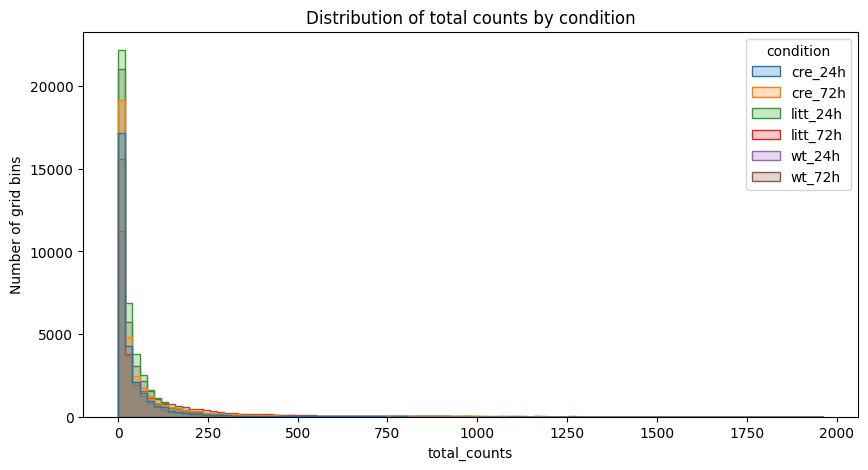

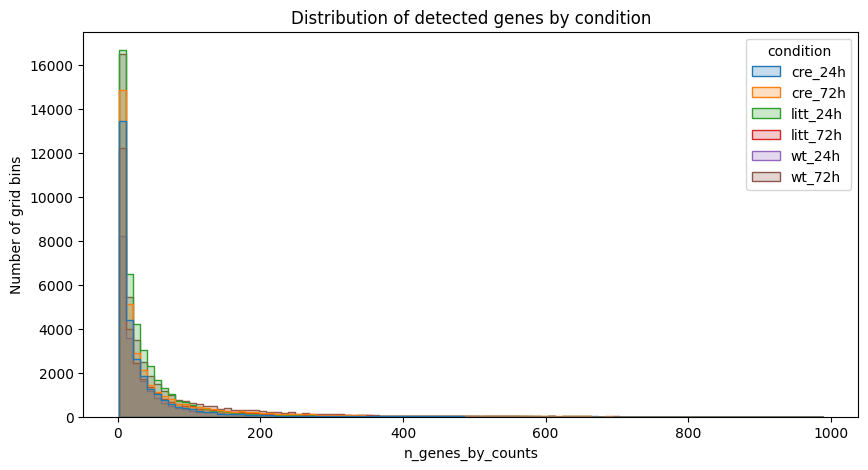

In [135]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(
    data=ad_merged.obs,
    x="total_counts",
    hue="condition",
    bins=100,
    element="step",
    common_norm=False,
)
plt.title("Distribution of total counts by condition")
plt.xlabel("total_counts")
plt.ylabel("Number of grid bins")
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(
    data=ad_merged.obs,
    x="n_genes_by_counts",
    hue="condition",
    bins=100,
    element="step",
    common_norm=False,
)
plt.title("Distribution of detected genes by condition")
plt.xlabel("n_genes_by_counts")
plt.ylabel("Number of grid bins")
plt.show()

In [136]:
print(len(ad_merged))
sc.pp.filter_cells(ad_merged,min_counts=10)
sc.pp.filter_cells(ad_merged,min_genes=5)
print(len(ad_merged))

200525
125232


/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [137]:
ad_merged.layers['counts'] = ad_merged.X.copy()

In [138]:
sc.pp.normalize_total(ad_merged, inplace=True,target_sum=100)
sc.pp.log1p(ad_merged)

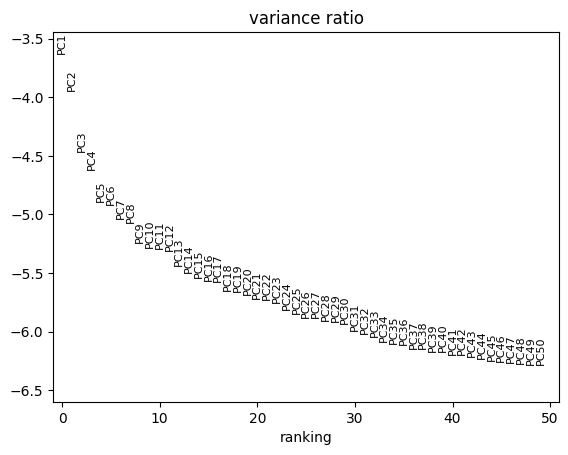

In [139]:
plt.rcdefaults()
sc.tl.pca(ad_merged)
sc.pl.pca_variance_ratio(ad_merged, n_pcs=50, log=True)
sc.pp.neighbors(ad_merged, n_neighbors=15, n_pcs=30)

In [140]:
sc.tl.umap(ad_merged, min_dist=0.1)

clustering at resolution 0.5


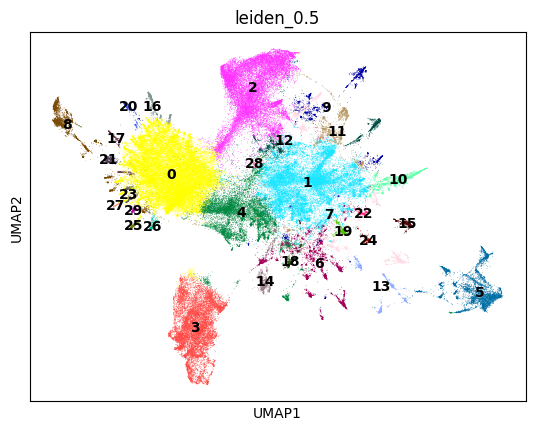

done
clustering at resolution 1


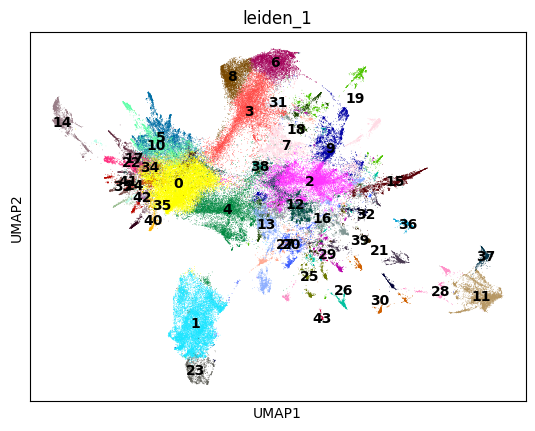

done


In [141]:
resolutions = [0.5, 1]
for resolution in resolutions: 
    print('clustering at resolution '+str(resolution))
    sc.tl.leiden(ad_merged, resolution = resolution, key_added = 'leiden_'+str(resolution))
    sc.pl.umap(ad_merged, color = 'leiden_'+str(resolution), legend_loc = 'on data')
    print("done")

In [142]:
import matplotlib.pyplot as plt

cre_24h


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_52919/2214177082.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_int, spot_size=30, color = 'leiden_0.5')


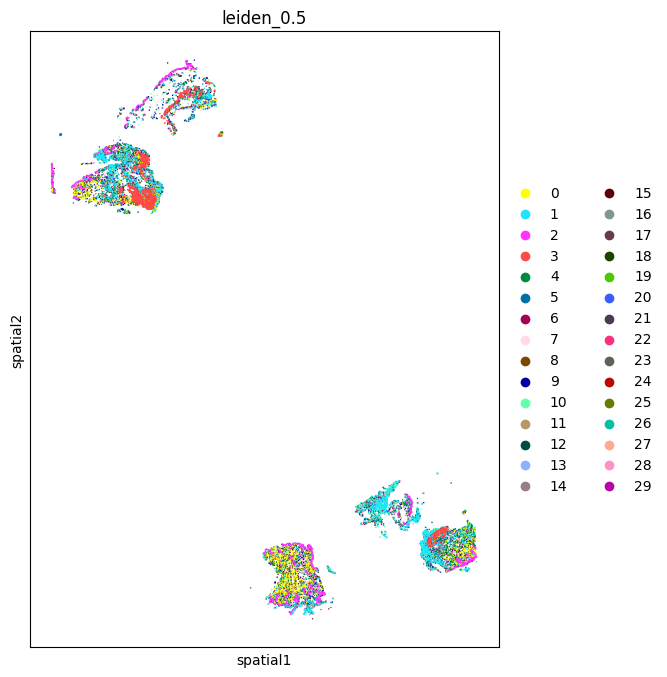

cre_72h


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_52919/2214177082.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_int, spot_size=30, color = 'leiden_0.5')


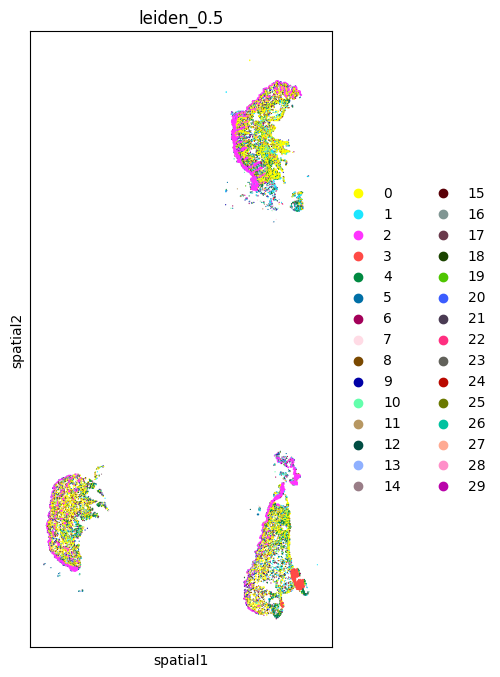

litt_24h


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_52919/2214177082.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_int, spot_size=30, color = 'leiden_0.5')


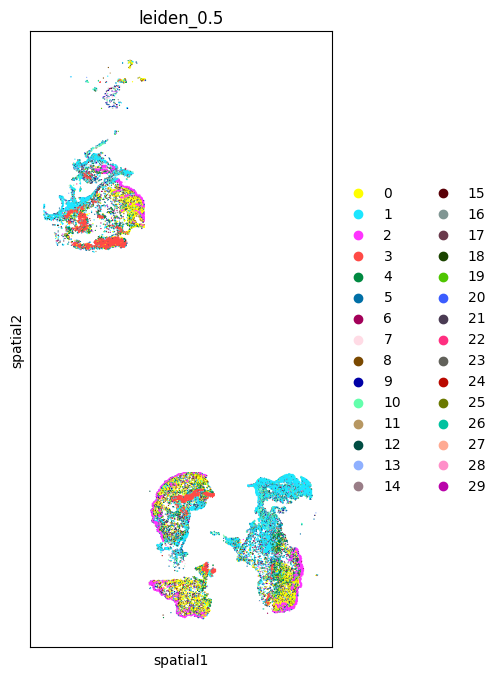

litt_72h


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_52919/2214177082.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_int, spot_size=30, color = 'leiden_0.5')


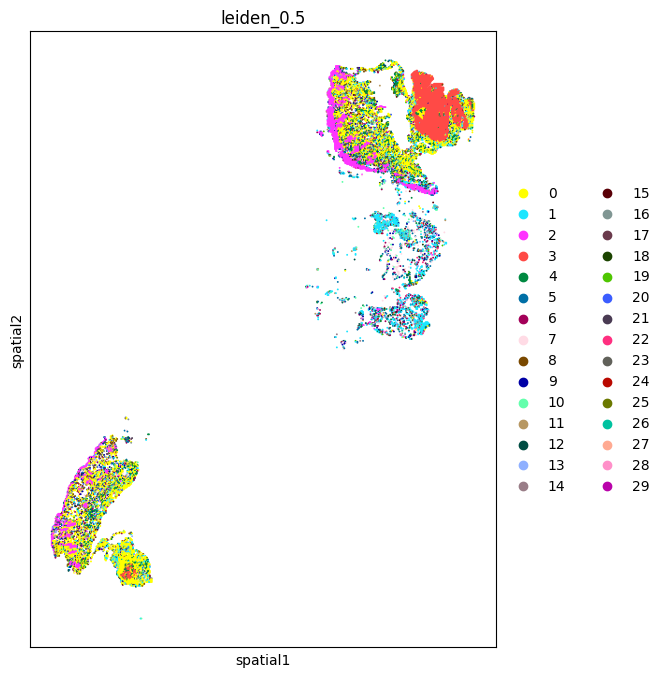

wt_24h


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_52919/2214177082.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_int, spot_size=30, color = 'leiden_0.5')


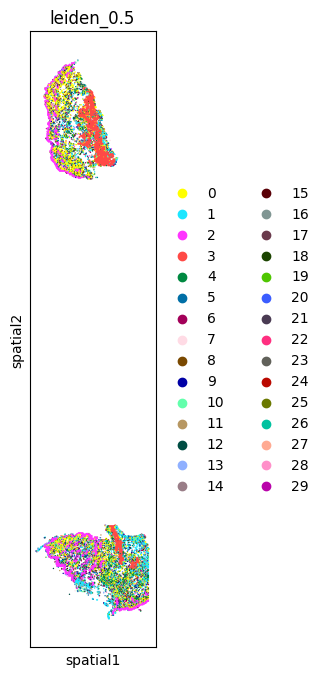

wt_72h


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_52919/2214177082.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_int, spot_size=30, color = 'leiden_0.5')


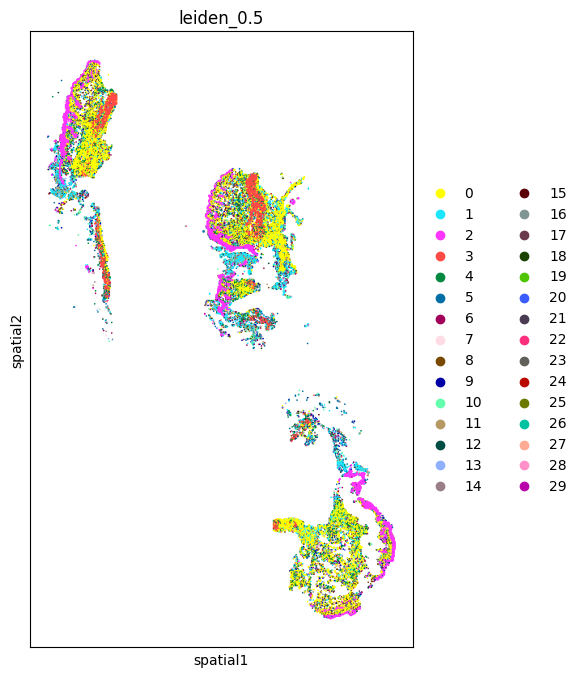

In [143]:
for grid in ad_merged.obs['condition'].unique():    
    ad_int = ad_merged[ad_merged.obs['condition'] == grid]
    print(ad_int.obs.condition.unique()[0])
    with plt.rc_context({'figure.figsize': (10, 8)}):
        sc.pl.spatial(ad_int, spot_size=30, color = 'leiden_0.5')
    plt.show()
